# Characterizing parameter uncertainty with MLE asymptotics

## Exposition

Recall that an MLE estimator converges in distribution to a normal distribution:

$$ \sqrt{n}(\hat{\theta}_{mle} - \theta) \to N(0, I^{-1}(\theta))$$

where $I(\theta)$ is the Fisher information matrix. Assuming the asymptotic approximation holds for $n = 6$, we can thus characterize parameter uncertainty by sampling from the distribution 

$$N(\hat{\theta}_{mle}, \hat{V})$$

where $\hat{V} = I^{-1}(\hat{\theta}_{mle})$.

We sample from the distribution by taking the Cholesky factor $\hat{V} = LL^T$, drawing $z \sim N(0, I)$, and calculating

$$ \theta^{(m)} = \hat{\theta}_{mle} + Lz^{(m)}$$

where $m$ indexes the random draws.

For our purposes, $\theta = (p_0, \xi, \sigma)$. To avoid bootstrapping, we further assume that $\hat{p_0}$ is independent from the estimators of the other two parameters. This is indeed asymptotically true, but again we're relying on wishful thinking.

## Code and results

Load libraries and data

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from numdifftools import Hessian
from scipy.optimize import minimize
from scipy import stats

To derive uncertainty distributions that respect parameter bounds, we reparametrize our parameters of interest as follows:

$$p_0 = \frac{1}{1 + e^{\phi_1}}$$

$$\xi = -1 + \ln(1 + e^{\phi_2})$$

$$\sigma = \ln({1 + e^{\phi_3}})$$


In [3]:
# Reparametrization transform

def transform_unconstrain(p, xi, sigma):
		phi_1 = np.log1p(-p) - np.log(p)
		phi_2 = np.log(np.exp(xi + 1) - 1)
		phi_3 = np.log(np.exp(sigma) - 1)

		return phi_1, phi_2, phi_3

def transform_constrain(phi_1, phi_2, phi_3):
		p = 1 / (1 + np.exp(phi_1))
		xi = np.log(1 + np.exp(phi_2)) - 1
		sigma = np.log(1 + np.exp(phi_3))

		return p, xi, sigma

In [4]:
# Load actual duration data
final_allrisk_ds = pd.read_csv("../../data/clean/final_allrisk_ds.csv")

intensity_data = final_allrisk_ds['intensity']
duration_data = final_allrisk_ds['duration']

intensity_annual = final_allrisk_ds.set_index('year_start')['intensity'].copy()

# Fill in zeros for years with no observations.
all_years = pd.Series(range(1900, 2023 + 1))
intensity_annual = intensity_annual.reindex(all_years, fill_value=0)

### Central estimates

Fit parameters using MLE. Check sensitivity to initial conditions and compare with canned estimator that doesn't give you covariance matrix out of the box.

In [81]:
# ------------------------------------------------------------------
# 2.  CHOOSE THRESHOLD  μ  (here: treat “arrival” as intensity > 0)
# ------------------------------------------------------------------
mu = 0.01                                   
excesses = intensity_data[intensity_data > mu] - mu
n_exceed   = excesses.size                 # years with a pandemic
n_years    = intensity_annual.size         # total years

# ------------------------------------------------------------------
# 3.  MLE for ξ and σ (GPD tail) - testing sensitivity to initial conditions
# ------------------------------------------------------------------
def neg_loglik(theta, y):
    xi, sigma = theta
    if sigma <= 0 or np.any(1 + xi * y / sigma <= 0):
        return np.inf                    # outside the parameter space
    n = y.size
    
    # Handle case where xi is close to zero
    if abs(xi) < 1e-6:
        # Use limit as xi->0: log(1 + xi*y/sigma) -> y/sigma
        return n * np.log(sigma) + np.sum(y/sigma)
    
    return n * np.log(sigma) + (1/xi + 1) * np.sum(np.log1p(xi*y/sigma))

# Try multiple starting points
start_points = [
    [0.1, excesses.mean()],  # Original starting point
    [0.5, excesses.mean()],
    [-0.1, excesses.std()],
    [0.2, excesses.median()],
    [3, excesses.mean()]
]

results = []
for start in start_points:
    opt = minimize(neg_loglik, start, args=(excesses,))
    results.append({
        'start': start,
        'xi': opt.x[0],
        'sigma': opt.x[1],
        'success': opt.success,
        'fun': opt.fun
    })

# Convert results list to pandas DataFrame and find best result
results_df = pd.DataFrame(results)
print("MLE estimates from different initial conditions")
display(results_df)

best_result = results_df.loc[results_df['fun'].idxmin()]
xi_hat, sigma_hat = best_result['xi'], best_result['sigma']

# Compare with scipy's genpareto fit
gp_fit = stats.genpareto.fit(excesses, floc=mu)
xi_hat_scipy, _, sigma_hat_scipy = gp_fit

print("\nParameter estimates comparison:")
print(f"Custom MLE (xi, sigma): ({xi_hat:.3f}, {sigma_hat:.3f})")
print(f"Scipy GPD (xi, sigma): ({xi_hat_scipy:.3f}, {sigma_hat_scipy:.3f})")

# ------------------------------------------------------------------
# 4.  Arrival probability  p₀  and its standalone variance
# ------------------------------------------------------------------
p0_hat   = n_exceed / n_years
var_p0   = p0_hat * (1 - p0_hat) / n_years    # Binomial variance


MLE estimates from different initial conditions


c:\Users\squaade\scoop\apps\anaconda3\current\App\envs\pandemic_model\Lib\site-packages\scipy\optimize\_numdiff.py:596: RuntimeWarning: invalid value encountered in subtract
  df = fun(x1) - f0
c:\Users\squaade\scoop\apps\anaconda3\current\App\envs\pandemic_model\Lib\site-packages\scipy\optimize\_numdiff.py:596: RuntimeWarning: invalid value encountered in subtract
  df = fun(x1) - f0
c:\Users\squaade\scoop\apps\anaconda3\current\App\envs\pandemic_model\Lib\site-packages\scipy\optimize\_numdiff.py:596: RuntimeWarning: invalid value encountered in subtract
  df = fun(x1) - f0
c:\Users\squaade\scoop\apps\anaconda3\current\App\envs\pandemic_model\Lib\site-packages\scipy\optimize\_numdiff.py:596: RuntimeWarning: invalid value encountered in subtract
  df = fun(x1) - f0


,start,xi,sigma,success,fun
0,"[0.1, 11.007339315909059]",1.009689,2.291994,True,17.034676
1,"[0.5, 11.007339315909059]",1.009694,2.291995,True,17.034676
2,"[-0.1, 22.519641875747737]",1.009692,2.292004,True,17.034676
3,"[0.2, 1.9207200922430427]",1.009691,2.291993,True,17.034676
4,"[3, 11.007339315909059]",1.009690,2.291991,True,17.034676



Parameter estimates comparison:
Custom MLE (xi, sigma): (1.010, 2.292)
Scipy GPD (xi, sigma): (1.014, 2.272)


Central estimates are not sensitive to a variety initial conditions and are very close to canned implementation of the MLE estimator.

### Covariance matrix

Next, we have three choices for computing the covariance matrix:
1. Use the approximation obtained for free from the MLE routine.
2. Use a more robust numerical Hessian approximation library.
3. Calculate and invert the analytical Fisher information matrix at the estimated parameters.

The Fisher information matrix for $(\xi, \sigma)$ in the code below was derived by o3. It's quite derivable, but requires detailed bookkeeping. I haven't found a reference to support the derivation.

Variance for p:
0.00037133698096740626
Covariance matrix from optimization routine:
[[ 0.49507686 -0.36205134]
 [-0.36205134  2.60064683]]

Covariance matrix from observed information:
[[ 0.49520256 -0.35986147]
 [-0.35986147  2.58436279]]

Covariance matrix from expected information:
[[ 0.67314293 -0.76769965]
 [-0.76769965  3.51912471]]


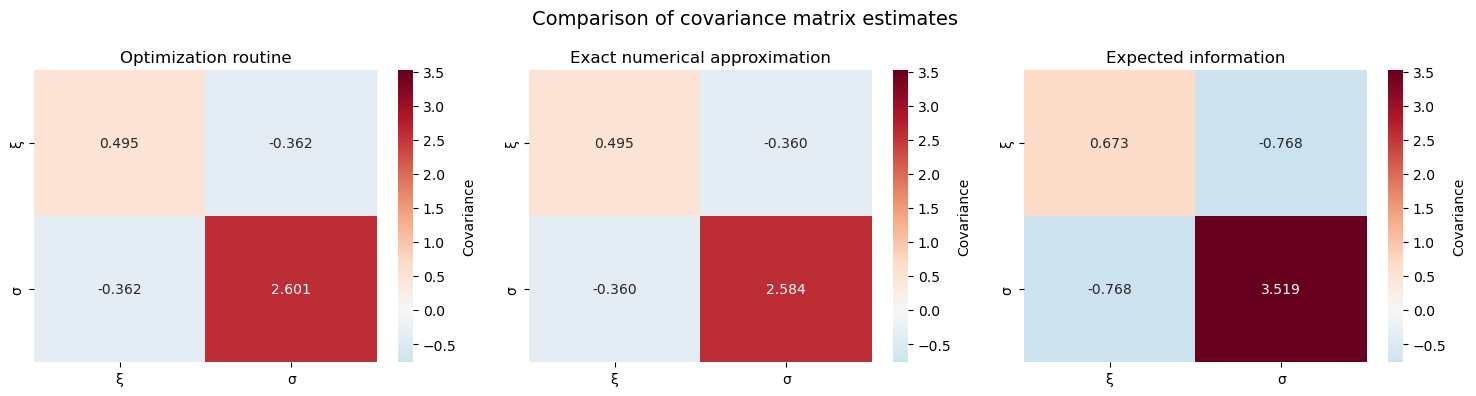

In [82]:
# Get implied covariance matrix from minimization routine
opt = minimize(neg_loglik, [best_result['start'][0], best_result['start'][1]], args=(excesses,), method='BFGS')
cov_tail = opt.hess_inv                  # 2×2 block for (xi, sigma)

# ---------------------------------------------------------------
# 3b.  Exact observed information with numdifftools  -------------
# ---------------------------------------------------------------
def nll_theta(theta):
    """Negative log-likelihood for one (xi, sigma) vector."""
    return neg_loglik(theta, excesses)

# 2×2 Hessian of the negative log-likelihood at the MLE
H_obs = Hessian(nll_theta)([xi_hat, sigma_hat])
V_tail_obs = np.linalg.inv(H_obs)      # observed-information covariance

# ---------------------------------------------------------------
# 3c.  Expected Fisher information (analytic)  -------------------
# ---------------------------------------------------------------
m = n_exceed              # shorthand: number of exceedances

def fisher_information_expected(xi: float, sigma: float, m: int) -> np.ndarray:
    """
    Expected Fisher-information matrix for (xi, sigma) based on `m`
    GPD exceedances, valid for xi > -0.5.

    Returns a 2×2 NumPy array:
        [[I_xi,xi,    I_xi,sig],
         [I_sig,xi,   I_sig,sig]]
    """
    if xi <= -0.5:
        raise ValueError("xi must be > -0.5 for moments to exist")

    denom = (1 + xi) * (1 + 2*xi)              # common denominator

    I_sig_sig = m / (sigma**2 * (1 + 2*xi))
    I_sig_xi  = m / (sigma * denom)
    I_xi_xi   = 2*m / denom

    return np.array([[I_xi_xi,   I_sig_xi],
                     [I_sig_xi,  I_sig_sig]])

I_exp      = fisher_information_expected(xi_hat, sigma_hat, m)
V_tail_exp = np.linalg.inv(I_exp)        # expected-information covariance

# Display the different covariance matrix estimates
print("Variance for p:")
print(var_p0)
print("Covariance matrix from optimization routine:")
print(cov_tail)
print("\nCovariance matrix from observed information:")
print(V_tail_obs)
print("\nCovariance matrix from expected information:")
print(V_tail_exp)

# Create a figure comparing the estimates
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Comparison of covariance matrix estimates', fontsize=14)

matrices = [cov_tail, V_tail_obs, V_tail_exp]
titles = ['Optimization routine', 'Exact numerical approximation', 'Expected information']

# Set consistent color scale across all plots
vmin = min(matrix.min() for matrix in matrices)
vmax = max(matrix.max() for matrix in matrices)

for ax, matrix, title in zip(axes, matrices, titles):
    # Use seaborn heatmap for better visualization
    sns.heatmap(matrix, 
                ax=ax,
                annot=True,
                fmt='.3f',
                cmap='RdBu_r',
                center=0,
                vmin=vmin,
                vmax=vmax,
                cbar_kws={'label': 'Covariance'})
    
    ax.set_title(title)
    ax.set_xticklabels(['ξ', 'σ'])
    ax.set_yticklabels(['ξ', 'σ'])

plt.tight_layout()


The matrices look quite similar. My view is that it would be most correct to use the sample-based approximations.

### Implied arrival distribution

Next, we propagate parameter uncertainty into our arrival distribution by simulating draws from the MLE asymptotic distribution using Cholesky factorization. We'll use the sample-based variance matrix estimate.

In [83]:
# ------------------------------------------------------------------
# 5.  Assemble the **full 3×3 covariance matrix**  V
#     (cross-covariances are zero in the PoT likelihood → block-diag)
# ------------------------------------------------------------------
V = np.zeros((3, 3))
V[0, 0]     = var_p0
V[1:, 1:]   = cov_tail    # insert the 2×2 block

theta_hat = np.array([p0_hat, xi_hat, sigma_hat])

# ------------------------------------------------------------------
# 6.  Cholesky factor once  +  simulate joint draws
# ------------------------------------------------------------------
L = np.linalg.cholesky(V)                 # V = L Lᵀ
n_sim = 100_000
Z     = np.random.randn(3, n_sim)         # each column ~ N(0,I)
theta_sim = theta_hat[:, None] + L @ Z    # θ̂ + L z

# Optional: keep parameters in their feasible ranges (safety clip)
theta_sim[0, :] = np.clip(theta_sim[0, :], 1e-8, 1 - 1e-8)   # p0
theta_sim[1, :] = np.clip(theta_sim[1, :], -1 + 1e-8, None)
theta_sim[2, :] = np.clip(theta_sim[2, :], 1e-8, None)       # sigma

# ------------------------------------------------------------------
# 8.  Summarise / visualise propagated uncertainty
# ------------------------------------------------------------------
print("Point estimates:")
print(f"   p0̂    = {p0_hat:.4f}")
print(f"   xî    = {xi_hat:.4f}")
print(f"   sigmâ = {sigma_hat:.4f}\n")

print("\nVariance-covariance matrix:")
print("   [p0, xi, sigma]")
print(V)


Point estimates:
   p0̂    = 0.0484
   xî    = 1.0097
   sigmâ = 2.2920


Variance-covariance matrix:
   [p0, xi, sigma]
[[ 3.71336981e-04  0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  4.95076858e-01 -3.62051343e-01]
 [ 0.00000000e+00 -3.62051343e-01  2.60064683e+00]]


In [84]:
MAX_INTENSITY = 57

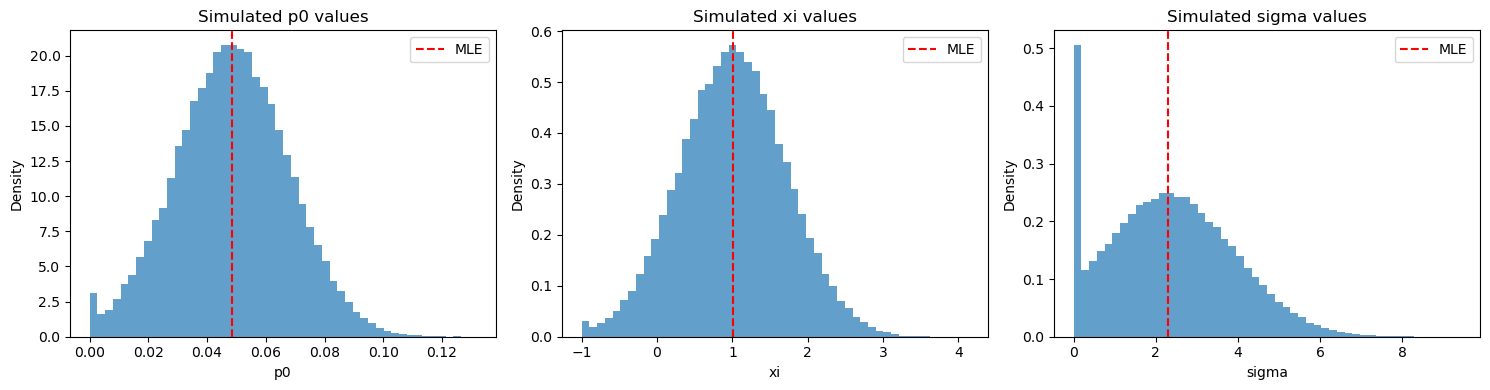

In [85]:
# Plot histograms of simulated parameters
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 4))

# p0 histogram
ax1.hist(theta_sim[0], bins=50, density=True, alpha=0.7)
ax1.axvline(p0_hat, color='r', linestyle='--', label='MLE')
ax1.set_title('Simulated p0 values')
ax1.set_xlabel('p0')
ax1.set_ylabel('Density')
ax1.legend()

# xi histogram  
ax2.hist(theta_sim[1], bins=50, density=True, alpha=0.7)
ax2.axvline(xi_hat, color='r', linestyle='--', label='MLE')
ax2.set_title('Simulated xi values')
ax2.set_xlabel('xi')
ax2.set_ylabel('Density')
ax2.legend()

# sigma histogram
ax3.hist(theta_sim[2], bins=50, density=True, alpha=0.7)
ax3.axvline(sigma_hat, color='r', linestyle='--', label='MLE')
ax3.set_title('Simulated sigma values')
ax3.set_xlabel('sigma')
ax3.set_ylabel('Density')
ax3.legend()

plt.tight_layout()
plt.show()

MLE based uncertainty ranges are quite wide. We've had to artificially clip the distributions at the bounds of their support (i.e. $\xi > -1, \sigma > 0$)

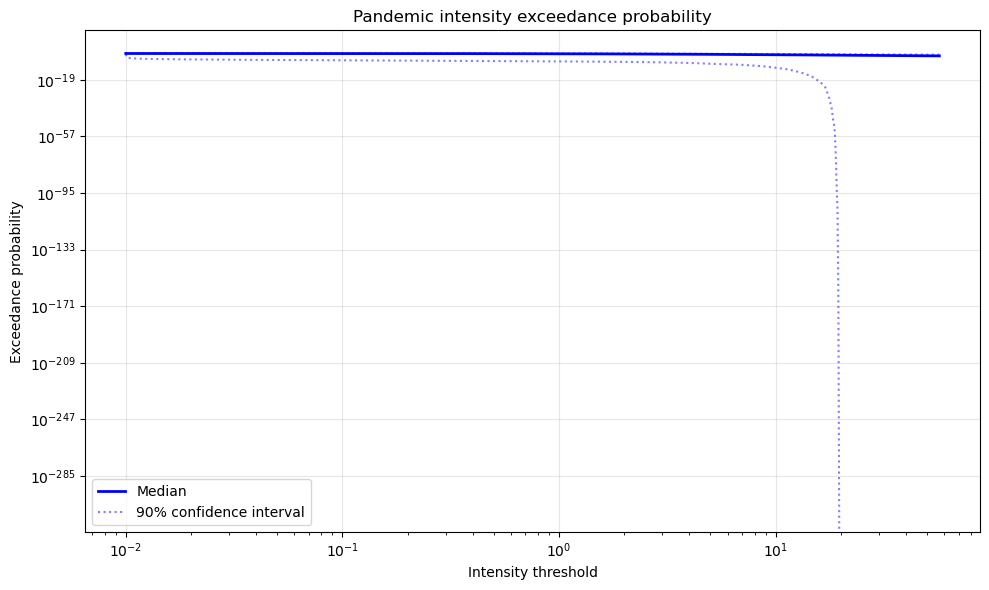

In [86]:
# Create intensity thresholds
intensity_thresholds = np.logspace(np.log10(mu), np.log10(MAX_INTENSITY), 1000)
intensity_thresholds_mat = np.tile(intensity_thresholds, (n_sim, 1)).T

# Calculate survival functions for each sample
intensity_survivals = (
    theta_sim[0] * stats.genpareto.sf(
        intensity_thresholds_mat,
        theta_sim[1],
        loc=mu,
        scale=theta_sim[2]
    )
)

# Calculate percentiles for credible intervals
intensity_percentiles = np.percentile(intensity_survivals, [5, 50, 95], axis=1)

# Plot exceedance probability curve
plt.figure(figsize=(10, 6))

# Plot median and credible intervals
plt.plot(intensity_thresholds, intensity_percentiles[1], 'b-', linewidth=2, label='Median')
plt.plot(intensity_thresholds, intensity_percentiles[0], 'b:', alpha=0.5, label='90% confidence interval')
plt.plot(intensity_thresholds, intensity_percentiles[2], 'b:', alpha=0.5)

plt.xscale('log')
plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.xlabel('Intensity threshold')
plt.ylabel('Exceedance probability')
plt.title('Pandemic intensity exceedance probability')
plt.legend()

plt.tight_layout()
plt.show()